In [1]:
import libs.append_path
from add_python_libraries import *
import pd_filter_fcns

import scipy as sp
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
import numpy as np
import numpy_rms
import cmath

#from buck_currents_fft import Iinp_FFT
from cyntec import Inductor_pdis, lparams,create_ind_family_df, ind_pdis_obj, l_set, cyntec_filename
from circuit_4state import circuit_params as circuit_params_4state
from circuit_2state import circuit_params as circuit_params_2state

from current_buck_waveforms import Current_buck_waveforms
from current_buck_fft import Current_buck_FFT

from capacitorZ_multibank import Zcapbanks
from current_capbanks_fft import Current_capbanks_FFT
from current_capbanks_waveforms import Current_capbanks_waveforms

In [2]:
input_params = {'vin' : 20,
                'vout': 11,
                'pin' : 99, 
                'eff' : 1, 
                'fs'  :400e3,
                'ton_mult':1,
                'tambient':25,
                'lout':{'family'   :'hbed053t',
                        'value(uH)':1.0,
                        'config'   :'single'},
                'lvl_config':'3 level',
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']

Csp   = {'label':'sp1','type':'sp',  'C':10e-6,  'ESR':100e-3, 'ESL':2e-9,   'n':1}
Cmlcc1 = {'label':'mlcc1','type':'mlcc','C':0.9e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4}
Cmlcc2 = {'label':'mlcc2','type':'mlcc','C':0.52e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':4}
Cmlcc3 = {'label':'mlcc3','type':'mlcc','C':0.052e-6, 'ESR':5e-3,   'ESL':0.5e-9, 'n':1}
Caplist = [Csp,Cmlcc1,Cmlcc2,Cmlcc3]

In [3]:
lobj = Inductor_pdis(input_params)
iobj = Current_buck_waveforms(lobj) 
time_datapoints = iobj.time_datapoints
I_inductor = iobj.i_ind
I_zin_ac = iobj.i_zin_ac

([<matplotlib.lines.Line2D at 0x2e3d2efaa60>],
 [<matplotlib.lines.Line2D at 0x2e3d2efad00>])

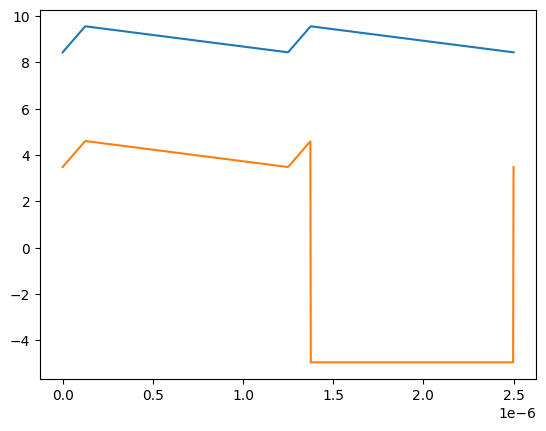

In [4]:
plt.plot(time_datapoints,I_inductor),plt.plot(time_datapoints,I_zin_ac)

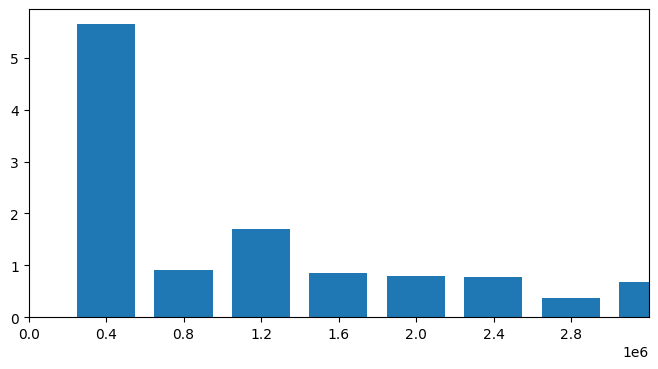

In [5]:
currents_buckfftobj = Current_buck_FFT(iobj)
currents_buckfftobj.plot_i_zin_fft()

In [6]:
zcapbanks = Zcapbanks(Caplist)
currents_capsfftobj = Current_capbanks_FFT(currents_buckfftobj,zcapbanks)

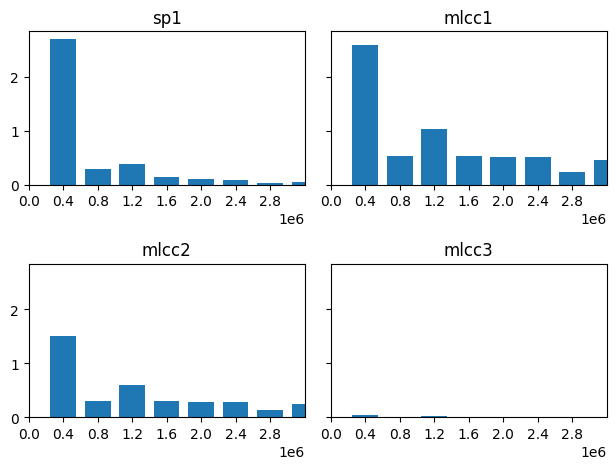

In [7]:
currents_capsfftobj.plot_i_allbanks_fft()

In [8]:
i_zbank_ac_obj = Current_capbanks_waveforms(currents_capsfftobj)

([<matplotlib.lines.Line2D at 0x2e3e951fcd0>],
 [<matplotlib.lines.Line2D at 0x2e3e94fc550>])

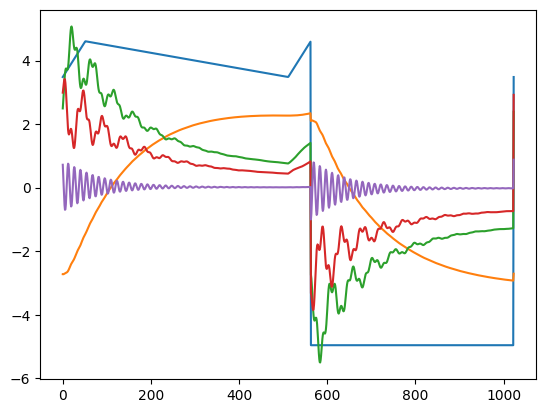

In [12]:
plt.plot(i_zbank_ac_obj.i_total_ac),plt.plot(i_zbank_ac_obj.i_nbanks_ac[0]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[1]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[2]),plt.plot(i_zbank_ac_obj.i_nbanks_ac[3])

In [ ]:
i_zbank_ac_obj.i_total_ac